In [336]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
df = pd.read_csv("../output/departures.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())


(51442, 17)
['stop_id', 'headsign', 'route', 'trip', 'vehicle_id', 'origin', 'destination', 'is_monitored', 'is_scheduled', 'is_istop', 'scheduled', 'expected', 'expected_mins', 'location', 'delay', 'queried_stop', 'timestamp']
    stop_id    headsign                                              route  \
0  GRGLIB:2  13N Silver  {'route_color': 'cccccc', 'route_id': 'SILVER'...   
1  GRGLIB:2  13N Silver  {'route_color': 'cccccc', 'route_id': 'SILVER'...   
2  GRGLIB:2  13N Silver  {'route_color': 'cccccc', 'route_id': 'SILVER'...   
3  GRGLIB:2    10W Gold  {'route_color': 'c7994a', 'route_id': 'GOLD', ...   
4  ARYWRT:5  13N Silver  {'route_color': 'cccccc', 'route_id': 'SILVER'...   

                                                trip  vehicle_id  \
0  {'trip_id': '[@6.0.28932250@][1][1654213960918...         NaN   
1  {'trip_id': '[@6.0.28932250@][1][1654525597845...         NaN   
2  {'trip_id': '[@6.0.28932250@][1][1654214032262...         NaN   
3  {'trip_id': '[@6.0.51699430@

In [337]:
print(df["is_monitored"].value_counts())
print(df["delay"].describe())
print(df.info())


is_monitored
True     48640
False     2802
Name: count, dtype: int64
count    51442.000000
mean         1.375318
std          2.689754
min         -2.450000
25%          0.000000
50%          0.000000
75%          1.633333
max         20.933333
Name: delay, dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 51442 entries, 0 to 51441
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   stop_id        51442 non-null  str    
 1   headsign       51442 non-null  str    
 2   route          51442 non-null  str    
 3   trip           51442 non-null  str    
 4   vehicle_id     48640 non-null  float64
 5   origin         51442 non-null  str    
 6   destination    51442 non-null  str    
 7   is_monitored   51442 non-null  bool   
 8   is_scheduled   51442 non-null  bool   
 9   is_istop       51442 non-null  bool   
 10  scheduled      51442 non-null  str    
 11  expected       51442 non-null  str    
 12  expected

In [338]:
min_timestamp = df["timestamp"][df.is_monitored == True].min()
min_timestamp
df["timestamp"] = pd.to_datetime(df.timestamp)


In [339]:
df_clean = df[(df.is_monitored == True) & (df.timestamp >= min_timestamp)]
df_clean.shape
df_clean.drop(df_clean[df_clean.stop_id == "testGRGLIB:2"].index, inplace=True)

In [340]:
print(df_clean["vehicle_id"].isna().sum())
print(df_clean["vehicle_id"].isna().sum() / len(df_clean) * 100)

0
0.0


In [341]:
to_drop = ["route", "origin", "destination", "is_monitored", "is_scheduled", "is_istop", "expected", "expected_mins", "location", "queried_stop"]
df_clean = df_clean.drop(to_drop, axis = 1)

In [342]:
print(df_clean.columns.tolist())
print(df_clean.shape)

['stop_id', 'headsign', 'trip', 'vehicle_id', 'scheduled', 'delay', 'timestamp']
(48639, 7)


In [343]:
df_clean[df_clean.duplicated()]

,stop_id,headsign,trip,vehicle_id,scheduled,delay,timestamp


In [344]:
df_clean = df_clean[df_clean.delay >= 0]
df_clean.shape

(48248, 7)

In [345]:
df_clean["scheduled"] = pd.to_datetime(df_clean["scheduled"])
df_clean["hour"] = df_clean["scheduled"].dt.hour

In [346]:
df_clean["Weekday"] = df_clean["timestamp"].dt.weekday
df_clean

,stop_id,headsign,trip,vehicle_id,scheduled,delay,timestamp,hour,Weekday
2802,GRGLIB:2,13N Silver,{'trip_id': '[@6.0.28932250@][1][1654213960918...,2019.0,2026-03-25 08:40:05-05:00,1.083333,2026-03-25 08:40:51.674757,8,2
2803,GRGLIB:2,22N Illini,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2017.0,2026-03-25 08:47:00-05:00,0.166667,2026-03-25 08:40:51.674757,8,2
2804,GRGLIB:2,13N Silver,{'trip_id': '[@6.0.28932250@][1][1654525597845...,2044.0,2026-03-25 08:50:05-05:00,0.000000,2026-03-25 08:40:51.674757,8,2
2805,GRGLIB:2,10W Gold,{'trip_id': '[@6.0.51699430@][32][171727017730...,1717.0,2026-03-25 08:53:20-05:00,0.000000,2026-03-25 08:40:51.674757,8,2
2806,GRGLIB:2,22N Illini,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2260.0,2026-03-25 08:57:00-05:00,0.000000,2026-03-25 08:40:51.674757,8,2
...,...,...,...,...,...,...,...,...,...
51437,PLAZA:4,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:18:00-05:00,20.283333,2026-03-27 19:36:57.493065,19,4
51438,IU:1,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:20:00-05:00,20.283333,2026-03-27 19:36:57.493065,19,4
51439,PLAZA:4,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:18:00-05:00,20.300000,2026-03-27 19:38:09.260260,19,4
51440,IU:1,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:20:00-05:00,20.550000,2026-03-27 19:38:09.260260,19,4


In [347]:
df_clean["Direction"] = df_clean["headsign"].str.extract(pat = '([NSEW])')
df_clean

,stop_id,headsign,trip,vehicle_id,scheduled,delay,timestamp,hour,Weekday,Direction
2802,GRGLIB:2,13N Silver,{'trip_id': '[@6.0.28932250@][1][1654213960918...,2019.0,2026-03-25 08:40:05-05:00,1.083333,2026-03-25 08:40:51.674757,8,2,N
2803,GRGLIB:2,22N Illini,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2017.0,2026-03-25 08:47:00-05:00,0.166667,2026-03-25 08:40:51.674757,8,2,N
2804,GRGLIB:2,13N Silver,{'trip_id': '[@6.0.28932250@][1][1654525597845...,2044.0,2026-03-25 08:50:05-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,N
2805,GRGLIB:2,10W Gold,{'trip_id': '[@6.0.51699430@][32][171727017730...,1717.0,2026-03-25 08:53:20-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,W
2806,GRGLIB:2,22N Illini,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2260.0,2026-03-25 08:57:00-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,N
...,...,...,...,...,...,...,...,...,...,...
51437,PLAZA:4,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:18:00-05:00,20.283333,2026-03-27 19:36:57.493065,19,4,N
51438,IU:1,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:20:00-05:00,20.283333,2026-03-27 19:36:57.493065,19,4,N
51439,PLAZA:4,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:18:00-05:00,20.300000,2026-03-27 19:38:09.260260,19,4,N
51440,IU:1,22N Illini,{'trip_id': '[@7.0.41200832@][1][1249401264125...,2261.0,2026-03-27 19:20:00-05:00,20.550000,2026-03-27 19:38:09.260260,19,4,N


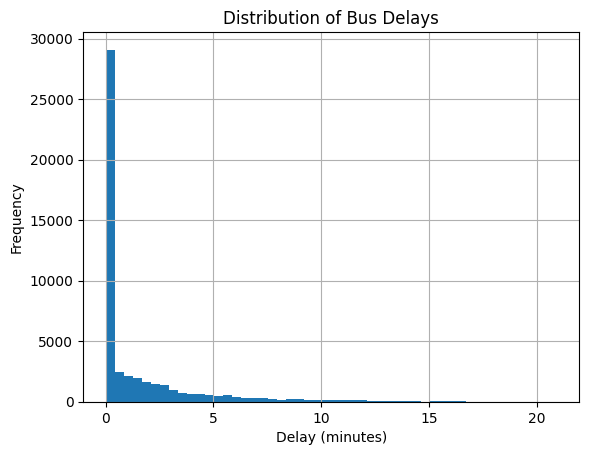

In [348]:

df_clean["delay"].hist(bins=50)
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Bus Delays")
plt.show()

In [349]:
df_clean= df_clean[df_clean.delay < 12]

In [350]:
print(df_clean.columns.tolist())
print(df_clean.shape)
print(df_clean.describe())
print(df_clean["stop_id"].value_counts())

['stop_id', 'headsign', 'trip', 'vehicle_id', 'scheduled', 'delay', 'timestamp', 'hour', 'Weekday', 'Direction']
(47617, 10)
         vehicle_id         delay                   timestamp          hour  \
count  47617.000000  47617.000000                       47617  47617.000000   
mean    2051.480165      1.299711  2026-03-26 12:24:25.847881     13.048701   
min     1346.000000      0.000000  2026-03-25 08:40:51.674757      6.000000   
25%     2017.000000      0.000000  2026-03-25 15:39:14.577188      9.000000   
50%     2022.000000      0.000000  2026-03-26 08:50:32.811110     13.000000   
75%     2364.000000      1.716667  2026-03-27 09:14:30.649516     17.000000   
max     2438.000000     11.983333  2026-03-27 19:16:37.902435     19.000000   
std      294.593163      2.320106                         NaN      3.943416   

            Weekday  
count  47617.000000  
mean       2.962156  
min        2.000000  
25%        2.000000  
50%        3.000000  
75%        4.000000  
max      

In [351]:
df_clean = pd.get_dummies(df_clean, prefix = ['Direction', 'Headsign', 'Stop ID'], columns = ["Direction", "headsign", "stop_id"], drop_first=True)
df_clean

,trip,vehicle_id,scheduled,delay,timestamp,hour,Weekday,Direction_N,Direction_W,Headsign_12E Teal Orchard Downs,Headsign_13N Silver,Headsign_22N Illini,Stop ID_ARYWRT:5,Stop ID_CHEMLS:1,Stop ID_GRGLIB:2,Stop ID_GRNGWN:7,Stop ID_GWNNV:4,Stop ID_IU:1,Stop ID_PLAZA:4
2802,{'trip_id': '[@6.0.28932250@][1][1654213960918...,2019.0,2026-03-25 08:40:05-05:00,1.083333,2026-03-25 08:40:51.674757,8,2,True,False,False,True,False,False,False,True,False,False,False,False
2803,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2017.0,2026-03-25 08:47:00-05:00,0.166667,2026-03-25 08:40:51.674757,8,2,True,False,False,False,True,False,False,True,False,False,False,False
2804,{'trip_id': '[@6.0.28932250@][1][1654525597845...,2044.0,2026-03-25 08:50:05-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,True,False,False,True,False,False,False,True,False,False,False,False
2805,{'trip_id': '[@6.0.51699430@][32][171727017730...,1717.0,2026-03-25 08:53:20-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,False,True,False,False,False,False,False,True,False,False,False,False
2806,{'trip_id': '[@7.0.41200832@][1][1238430123625...,2260.0,2026-03-25 08:57:00-05:00,0.000000,2026-03-25 08:40:51.674757,8,2,True,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51333,{'trip_id': '[@6.0.28932250@][1][1654523182068...,2043.0,2026-03-27 19:13:00-05:00,2.416667,2026-03-27 19:13:03.484543,19,4,True,False,False,True,False,False,False,False,False,False,True,False
51340,{'trip_id': '[@6.0.28932250@][1][1654523182068...,2043.0,2026-03-27 19:12:00-05:00,3.016667,2026-03-27 19:14:15.135636,19,4,True,False,False,True,False,False,False,False,False,False,False,True
51342,{'trip_id': '[@6.0.28932250@][1][1654523182068...,2043.0,2026-03-27 19:13:00-05:00,3.016667,2026-03-27 19:14:15.135636,19,4,True,False,False,True,False,False,False,False,False,False,True,False
51350,{'trip_id': '[@6.0.28932250@][1][1654523182068...,2043.0,2026-03-27 19:13:00-05:00,3.250000,2026-03-27 19:15:26.726998,19,4,True,False,False,True,False,False,False,False,False,False,True,False


In [354]:
ind = ["hour", "Weekday", "Direction_N", "Direction_W", "Headsign_12E Teal Orchard Downs", "Headsign_13N Silver", "Headsign_22N Illini","Stop ID_ARYWRT:5", "Stop ID_CHEMLS:1", "Stop ID_GRGLIB:2", "Stop ID_GRNGWN:7", "Stop ID_GWNNV:4", "Stop ID_IU:1", "Stop ID_PLAZA:4"]

model = LinearRegression()
model.fit(df_clean[ind], df_clean[dep])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [355]:
model.coef_

array([[ 0.09495354, -0.21711606, -0.12831867, -0.08085283,  0.2091715 ,
        -0.58257952,  0.45426085, -0.0465284 , -0.87825541, -0.57056946,
        -0.7920238 , -0.8000083 , -0.03017163,  0.05562612]])

In [356]:
model.intercept_

array([1.04376443])

In [357]:
model.score(df_clean[ind], df_clean[dep])

0.09128383969791776

In [359]:
print(len(df_clean.columns.tolist()))

19


In [360]:
#export as csv
df_clean.to_csv("../output/departures_clean.csv", index = False)